# MUFG Data Science Challenge 2025: 予測モデル構築チュートリアル

本ノートブックでは、中小企業の融資属性データ（融資額、利率、期間、事業形態等）に基づき、将来的な債務不履行（デフォルト）の発生を予測するバイナリ分類タスクに取り組みます。

実行環境は Google Colaboratory を想定しており、以下のステップに従って解析を進めます。

1. **環境構築**: Google Drive のマウント
2. **ライブラリ準備**: 解析に必須なライブラリのインポート
3. **データロード**: データの読み込みと基本情報の確認
4. **探索的データ分析 (EDA)**: データの視覚化と傾向把握
5. **前処理**: 特徴量エンジニアリングとデータ分割
6. **モデル構築**: 学習とバリデーション（交差検証）
7. **推論と提出**: 予測の実行と提出ファイルの作成

チュートリアルの最後には精度向上のための指針も提示しています。本コードをベースラインとして、さらなる精度改善に挑戦してください。

# 1. 実行環境のセットアップ（Google Drive のマウント）
Google Colaboratory 上でデータを効率的に管理・読み込むため、Google Drive を仮想ドライブとしてマウントします。

これにより、ローカル環境から毎回アップロードする手間を省き、永続的なデータアクセスが可能になります。

それではまずGoogle DriveをGoogle Colabolatoryにマウントします。

Google Driveをマウントすることで、ColabノートブックがDrive内のデータに直接アクセスできるようになります。

以下のコードを実行して、ドライブをマウントしてください。


> 「このノートブックに Google ドライブのファイルへのアクセスを許可しますか？」や「アカウントの選択」・「Drive for DeskTop」などの利用許可

が出ると思いますが、「許可する」をクリックすることでマウントが可能になります。

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


マウントは問題なく実行できていれば、`Mounted at /content/drive`と出力されます。

左のタブからフォルダの画像をクリックすると、driveというフォルダが出現します。その中のMy DriveにGoogle Driveに格納されているデータが確認できます。次はそこに格納されているデータを読み込み、中身を確認していきます。

# 2. データ解析ライブラリのインポート
Python におけるデータサイエンスの標準的なライブラリ群を導入します。

- **pandas**: 表形式データの効率的な操作と加工をサポートします。
- **numpy**: 高度な数値計算と多次元配列の処理を可能にします。
- **matplotlib / seaborn**: データの傾向を直感的に把握するための強力な視覚化ツールです。

In [2]:
# ライブラリのimportを行います
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ここで登場する`as`はpandasのライブラリなどをpdと省略して呼び出すことができます。

`as`はコードをわかりやすく、簡潔に記載するには重要な要素です。分析の内容自体に大きな影響はありませんが覚えておくと良いでしょう。



# 2.データの読み込みと確認
本チュートリアルでのフォルダ(ディレクトリ)の構造は以下を想定しております。
<code>
MUFG Data Science Challenge 2025<br>
│<br>
BasicCamp<br>
├─data<br>
│  ├─train.csv<br>
│  └─test.csv<br>
│  └─submit_sample.csv<br>
│  └─description.txt<br>
└─tutorial.ipynb
</code>

それではデータを`pd.read_csv()`読み込んでみましょう。

google driveをマウントしている場合、該当するデータがdrive上に存在します。

In [3]:
# 自分のドライブにマウントしているとドライブ上のファイルを読み込むことができます。
train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MUFG Data Science Challenge 2025/BasicCamp/data/train.csv")
test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MUFG Data Science Challenge 2025/BasicCamp/data/test.csv")

※左のタブのフォルダの画像から、drive上のフォルダを探せます。ここではフォルダ名を「MUFG Data Science Challenge 2025」としているので、`/content/drive`内に存在する「MUFG Data Science Challenge 2025」のフォルダを探しましょう。見つけたら、train.csvとtest.csvを右クリックし、「パスをコピー」をクリックして、`pd.read_csv()`内に貼り付けます。

読み込めましたら、次にデータの中身を簡単に見てみましょう。

In [4]:
train.head()

,id,GrossApproval,SBAGuaranteedApproval,ApprovalFiscalYear,Subprogram,InitialInterestRate,FixedOrVariableInterestInd,TermInMonths,NaicsSector,CongressionalDistrict,BusinessType,BusinessAge,RevolverStatus,JobsSupported,CollateralInd,LoanStatus
0,1,23000,7093,2020,FA$TRK (Small Loan Express),11.92,V,84,Accommodation_food services,27,CORPORATION,Unanswered,0,1,N,1
1,2,104300,83477,2020,FA$TRK (Small Loan Express),8.40,V,102,Retail trade,14,CORPORATION,"Startup, Loan Funds will Open Business",1,1,N,1
2,3,163900,53246,2020,Contract Guaranty,4.32,F,119,Construction,0,CORPORATION,Existing or more than 2 years old,1,79,Y,0
3,4,127400,77516,2021,Guaranty,6.40,F,59,Information,3,CORPORATION,Existing or more than 2 years old,0,2,N,0
4,5,2128900,858942,2020,Guaranty,5.21,V,300,Health care_social assistance,44,CORPORATION,New Business or 2 years or less,0,5,Y,0


In [5]:
test.head()

,id,GrossApproval,SBAGuaranteedApproval,ApprovalFiscalYear,Subprogram,InitialInterestRate,FixedOrVariableInterestInd,TermInMonths,NaicsSector,CongressionalDistrict,BusinessType,BusinessAge,RevolverStatus,JobsSupported,CollateralInd
0,7553,22900,10607,2021,FA$TRK (Small Loan Express),4.30,F,5,Arts_entertainment_recreation,24,CORPORATION,Existing or more than 2 years old,0,10,Y
1,7554,29000,13390,2020,FA$TRK (Small Loan Express),6.97,V,120,Wholesale trade,5,INDIVIDUAL,New Business or 2 years or less,0,0,Y
2,7555,2913000,1737254,2020,Guaranty,5.61,V,200,Manufacturing,1,CORPORATION,"Startup, Loan Funds will Open Business",0,96,Y
3,7556,39200,24755,2022,FA$TRK (Small Loan Express),10.00,V,85,Other services (except public administration),11,CORPORATION,Unanswered,1,12,N
4,7557,13600,5064,2020,FA$TRK (Small Loan Express),7.34,V,39,Other services (except public administration),1,CORPORATION,Existing or more than 2 years old,0,0,N


データの一部が見えました。

このデータには特徴量として以下の要素が確認できます。

- id: データID
- GrossApproval: 融資承認額（総額）
- SBAGuaranteedApproval: 融資額の補償金額
- ApprovalFiscalYear: 融資承認年度
- Subprogram: ローンの種類
- InitialInterestRate: 初期金利
- FixedOrVariableInterestInd: 固定金利(F)または変動金利(V)
- TermInMonths: 融資期間（月単位）
- NaicsSector: 産業の大分類
- CongressionalDistrict: 借入者の住所が属する選挙区
- CORPORATION: 借入者の事業形態
- BusinessAge: 事業の年数区分
- RevolverStatus: 定期貸付（0）かリボルビング（1）か
- JobsSupported: 借入者事業者の雇用数（借入者の自己申告）
- CollateralInd: 担保の有無（借入者の自己申告）
- LoanStatus: ローンの状態(目的変数: 1 = デフォルト, 0 = デフォルトしていない)


本コンペティションではtestデータの債務不履行の有無(LoanStatus)を正確に予測する必要があります。

このため予測対象であるtestデータにはLoanStatusがありません。

次にデータの形状をみてみましょう。
データがいくつ存在するのか、特徴量が何個あるかがわかります。

In [6]:
print(train.shape)
print(test.shape)

(7552, 16)
(7552, 15)


訓練データは7552行・16列のデータがあり、テストデータは7552行・15列のデータがありました。

テストデータが1列少ないのは、LoanStatusの項目がないためです。

それでは最後に欠損値の確認を行いましょう。

欠損値は「データが存在しない」ことを意味します。

これらを確認することで、どのデータがどれくらい情報を保持しているのかなどがわかります。

`train.isnull().sum()`で欠損値の確認ができます。

In [7]:
train.isnull().sum().sort_values(ascending=False)

,0
id,0
GrossApproval,0
SBAGuaranteedApproval,0
ApprovalFiscalYear,0
Subprogram,0
InitialInterestRate,0
FixedOrVariableInterestInd,0
TermInMonths,0
NaicsSector,0
CongressionalDistrict,0


In [8]:
test.isnull().sum().sort_values(ascending=False)

,0
id,0
GrossApproval,0
SBAGuaranteedApproval,0
ApprovalFiscalYear,0
Subprogram,0
InitialInterestRate,0
FixedOrVariableInterestInd,0
TermInMonths,0
NaicsSector,0
CongressionalDistrict,0


学習データ・テストデータどちらにも欠損値は存在しませんでした。

欠損値がある場合、一部モデルでは学習のために補完や削除などを行う必要がありますが、このデータでは欠損値がないためそのような処理は不要となります。

# 3. 探索的データ分析 (EDA)
視覚化は、統計量だけでは見えてこないデータの傾向を把握するために極めて重要です。

特徴量の分布や目的変数（LoanStatus）との相関を分析することで、予測に寄与する重要な変数を特定し、モデル改善の仮説を立てることが可能になります。

本セクションではまず、目的変数であるデフォルト発生率の全体的な分布を確認します。

まずデフォルト情報の全体的な傾向を見てみます。

デフォルト情報はデフォルトしたかそうでないかを、0か1で表すデータのため、0と1の出現数を確認することで分布を確認できます。

出現数を計算するには`value_counts()`を利用します。

ここでは割合を計算するために()内にnormalize=Trueを含めます。

In [9]:
train["LoanStatus"].value_counts(normalize=True)

,proportion
LoanStatus,
0,0.872352
1,0.127648


デフォルトしていない方が全体の約87%あり、0の方が多いことがわかりました。

では次はこれをグラフ化してみましょう。

2つのデータの大小を比較するので、棒グラフで比較します。

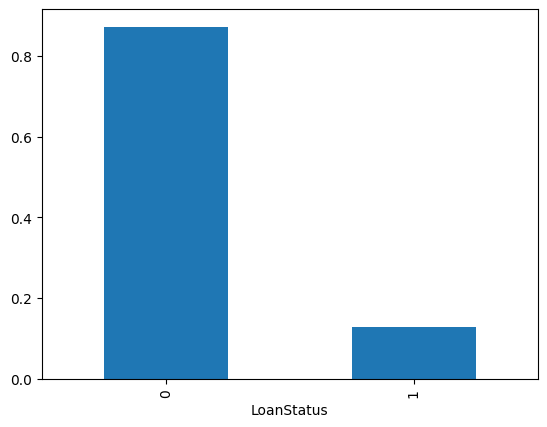

In [10]:
LoanStatus_value_count = train["LoanStatus"].value_counts(normalize=True)
LoanStatus_value_count.plot.bar()
plt.show()

先ほどの結果通り、デフォルトしていない0のデータが多いことがわかりました。

出現数を単に比較したい場合は、上記のコードで確認したい特徴量を変えると別の特徴量でも比較ができます。

なお可視化の別の方法として以下でも可能です。

この方法は、柔軟に棒グラフを作成できる特徴があります。少し複雑そうに見えますが、x軸にデータの要素を、y軸に要素の集計結果を入れれば、同様な可視化が可能です。(工夫次第では横向きのグラフにすることも可能性です)

```
# plt.bar(x軸, y軸)
plt.bar(LoanStatus_value_count.index, LoanStatus_value_count.values)
#plt.xlabel(), plt.ylabel()で縦軸と横軸の名前を決められます。
plt.xlabel("LoanStatus")
plt.ylabel("count")
plt.show()
```

それでは次に他の特徴量の関係性について確認してみましょう。

与えられた特徴量でデフォルト率に関係がありそうなものは色々ありますが、わかりやすそうな、`NaicsSector(産業の大分類)`、`TermInMonths(融資期間)`、`GrossApproval(融資の総額)`を確認してみましょう。

`NaicsSector(産業の大分類)`はカテゴリデータ、

`TermInMonths(融資期間)`、`GrossApproval(融資の総額)`は数値データ、

です。

それぞれどのように傾向をグラフ化するのか確認してみましょう。

### NaicsSectorとLoanStatusの関係

まずNaicsSector(産業の大分類)を見ていきましょう。

大分類を確認するとカテゴリデータのため、カテゴリごとにデフォルト率を算出すれば、傾向が見えてきそうです。

In [11]:
train["NaicsSector"].head()

,NaicsSector
0,Accommodation_food services
1,Retail trade
2,Construction
3,Information
4,Health care_social assistance


それぞれのカテゴリごとに一つ一つデフォルト率を算出する方法もありますが、それは面倒なので、`groupby`で一括して行う方法を取ります。

`groupby`は集計のコードで、excelで例えると、ピボットテーブルに近い機能を持ちます。

以下のコードで実行できます。

In [12]:
train.groupby("NaicsSector")["LoanStatus"].mean()

,LoanStatus
NaicsSector,
Accommodation_food services,0.124413
Administrative_support_waste management_remediation services,0.145098
Agriculture_forestry_fishing_hunting,0.025478
Arts_entertainment_recreation,0.157895
Construction,0.147993
Educational services,0.051852
Finance_insurance,0.028436
Health care_social assistance,0.142857
Information,0.042553


確認できましたが、データ量が多いので、グラフ化して一気に比較してみましょう!

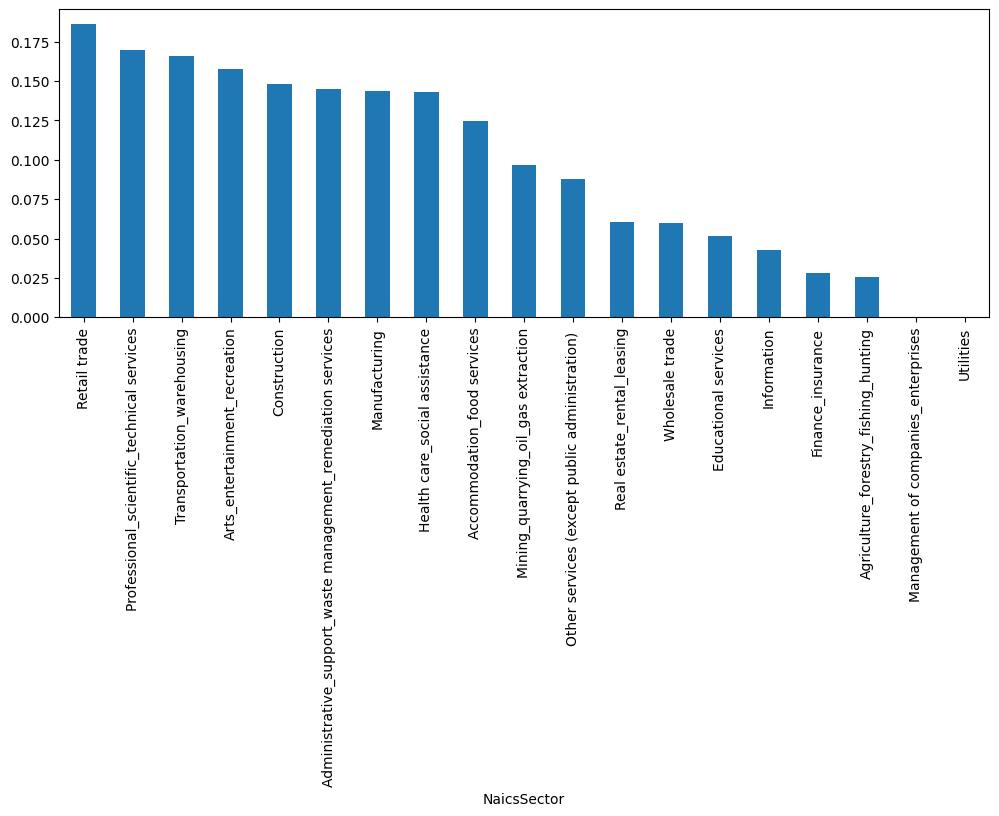

In [13]:
# 確認する量が多いのでグラフを大きくして可視化しています
plt.figure(figsize=(12, 4))
train.groupby("NaicsSector")["LoanStatus"].mean().sort_values(ascending=False).plot.bar()
plt.show()

最もデフォルト率が高かったのは、Reatil Trade(小売業)でした!

全体のデフォルトの確率が約12.7%程度だったのに対し、小売業は約17.5%と、周りと比べても5%程デフォルト率が高いですね!

また一方で、デフォルト率が0%のデータも存在します。

こちらは本当に0%なのか、データが少なくて偶然0%になっている可能性もあります。

実際に確認してみましょう。

In [14]:
print(train[train["NaicsSector"] == "Management of companies_enterprises"].shape)

(9, 16)


In [15]:
print(train[train["NaicsSector"] == "Utilities"].shape)

(30, 16)


どちらもサンプル数としては少なめですね。

こういったサンプル数の少ないデータは例外として扱う方法もあります。

ですがこのチュートリアルでは、例外として扱かわずこのまま利用します。

もしこの扱いが気になる場合は、チュートリアル後の次の段階として例外として扱う方法も考えてみましょう。

例えば、要素数が50以下のカテゴリは、"Other"として扱うなどが考えられます。

`vc_dict = train["NaicsSector"].value_counts().to_dict()`<br>
`train.loc[train["NaicsSector"].map(vc_dict) <= 50, "NaicsSector"] = "Other"`

### TermInMonths, GrossApprovalとLoanStatusの関係

では次に期間や総額などの数値データとの関係性を見ていきましょう。

カテゴリとは別の方法で見ていきます。

In [16]:
# データの値を確認しています
train[["TermInMonths", "GrossApproval"]].head()

,TermInMonths,GrossApproval
0,84,23000
1,102,104300
2,119,163900
3,59,127400
4,300,2128900


まず数値データについては、全体の分布を確認していましょう。

ヒストグラムでも良いですが、ここは`describe()`を使って大まかな統計量を確認します。

In [ ]:
train[["TermInMonths", "GrossApproval"]].describe()

,TermInMonths,GrossApproval
count,7552.000000,7.552000e+03
mean,119.854211,7.219039e+05
std,82.423821,1.112669e+06
min,3.000000,5.000000e+03
25%,60.000000,5.110000e+04
50%,119.000000,1.896000e+05
75%,120.000000,8.113000e+05
max,306.000000,4.995000e+06


GrossApprovalは全体的に値が大きいことがわかりました。


まずデフォルトするかしないかで、TermInMonthsとGrossApprovalの値に変動があるかどうかを確認してみましょう。

In [17]:
train.groupby("LoanStatus")["TermInMonths"].mean()

,TermInMonths
LoanStatus,
0,125.623406
1,80.427386


In [18]:
train.groupby("LoanStatus")["GrossApproval"].mean()

,GrossApproval
LoanStatus,
0,780791.469338
1,319465.041494


基本的にデフォルトする方が、値が小さくなる傾向にありそうです。(つまり期間が短いほど、融資の総額が小さいほどデフォルトしやすくなります)

ですが最大値と最小値の値の差が非常に大きく、その影響もあると思いますので、他の視点でも確認してみましょう。

他の視点として相関係数を見て確認していきます。

相関係数は、データの関係性を確認できる方法です。一般的に連続する数値同士の関係性を見るのに使います。

今回の場合、デフォルトするかしないかを0と1で表現しているデータと比較します。

一見すると関係性の確認がしにくいように見えますが、多少の傾向であれば相関係数で確認ができますので実際に見てみましょう。

In [19]:
# corr()で相関係数を見ることができます。
train[["TermInMonths", "GrossApproval", "LoanStatus"]].corr()

,TermInMonths,GrossApproval,LoanStatus
TermInMonths,1.000000,0.402922,-0.182991
GrossApproval,0.402922,1.000000,-0.138364
LoanStatus,-0.182991,-0.138364,1.000000


LoanStatusとTermInMonthsは-0.18、GrossApprovalは-0.14とどちらも負の相関、つまり、値が小さければ、デフォルトしやすくなる傾向があると言えそうです。

それを確認するために、最後にデフォルトする時としない時でのデータの出現率の違いを確認してみましょう!

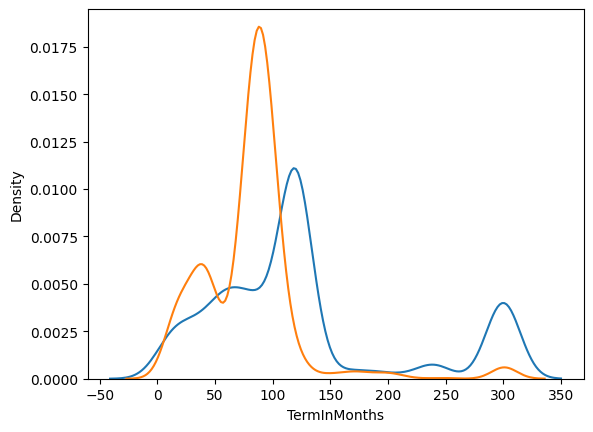

In [20]:
# kdeplotでデータの出現率の分布を確認できます。
sns.kdeplot(train[train["LoanStatus"] == 0]["TermInMonths"])
sns.kdeplot(train[train["LoanStatus"] == 1]["TermInMonths"])
plt.show()

上記分布は、データの出現率を表しているグラフで、上に行くほど出現率が高い傾向を表します。

(青がデフォルトしない時の分布、オレンジがデフォルトする時の分布です。)

この結果を見ると、TermInMonthsについては、短い方がデフォルトする確率が高いと言えそうです。

同様にGrossApprovalも見てみましょう!

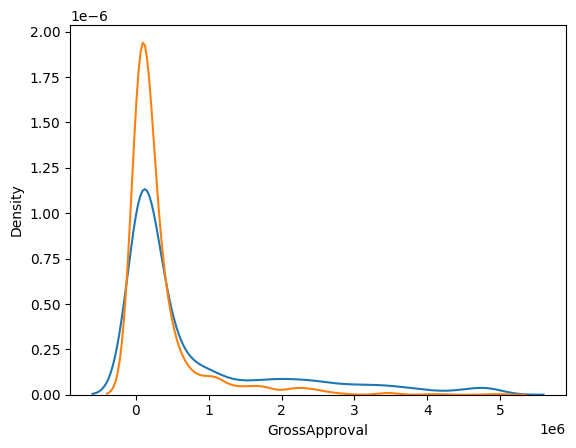

In [21]:
sns.kdeplot(train[train["LoanStatus"] == 0]["GrossApproval"])
sns.kdeplot(train[train["LoanStatus"] == 1]["GrossApproval"])
plt.show()

相関係数の通り、GrossApprovalが小さい方がデフォルトする可能性が高いと言えそうです。

チュートリアルの可視化はここまでですが、上記の特徴量以外にもさまざまな特徴量が存在します。

チュートリアルが終わり次第、仮説を立てて他の特徴量とデフォルト率との関係を可視化してみましょう。

このチュートリアルのグラフ化だけでも一定確認できますが、他にも様々なグラフが用意されていますので、興味がありましたら新たな可視化も試してみましょう!

# 4. 特徴量エンジニアリングとデータ分割
モデルの性能を最大限に引き出すため、生データをアルゴリズムに適した形式に変換する「前処理」と、モデルの汎化性能（未知のデータに対する予測力）を正しく評価するための「データ分割」を行います。

まず使用する特徴量の選定を行います。

チュートリアルでは、確認した`NaicsSector, TermInMonths, GrossApproval`に加えて、`ApprovalFiscalYear, BusinessType`も含めてモデルの学習を行います。

学習対象となる特徴量と予測対象の`LoanStatus`を抽出します。

In [22]:
target = train["LoanStatus"]
train = train[["TermInMonths", "GrossApproval", "ApprovalFiscalYear", "NaicsSector", "BusinessType"]]
test = test[["TermInMonths", "GrossApproval", "ApprovalFiscalYear", "NaicsSector", "BusinessType"]]

それでは前処理を行います。

まずカテゴリデータを数値に変換しましょう。AIモデルなどは学習時にカテゴリデータをそのまま入力することはできません。そのためデータを、数値に変換する必要があります。

カテゴリ変数を数値に変更する方法は様々ありますが、

- ラベルエンコーディング
- ダミー変数
- カウントエンコーディング
- ターゲットエンコーディング

本チュートリアルではわかりやすさのために、ダミー変数を用いて変換を行います。

ダミー変数とはカテゴリデータ内の特定の要素の有無を1と0で表す方法です。

それではやってみましょう。

In [23]:
# pd.get_dummies(データ, columns=[ダミー変数にしたい特徴量])でダミー変数に変換できます。
# columns=[変換したいカテゴリデータ] でダミー変数化する特徴量を指定することができます。
train = pd.get_dummies(train, columns=["NaicsSector", "BusinessType"])
test = pd.get_dummies(test, columns=["NaicsSector", "BusinessType"])

In [24]:
train.head()

,TermInMonths,GrossApproval,ApprovalFiscalYear,NaicsSector_Accommodation_food services,NaicsSector_Administrative_support_waste management_remediation services,NaicsSector_Agriculture_forestry_fishing_hunting,NaicsSector_Arts_entertainment_recreation,NaicsSector_Construction,NaicsSector_Educational services,NaicsSector_Finance_insurance,...,NaicsSector_Professional_scientific_technical services,NaicsSector_Real estate_rental_leasing,NaicsSector_Retail trade,NaicsSector_Transportation_warehousing,NaicsSector_Utilities,NaicsSector_Wholesale trade,BusinessType_,BusinessType_CORPORATION,BusinessType_INDIVIDUAL,BusinessType_PARTNERSHIP
0,84,23000,2020,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,102,104300,2020,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
2,119,163900,2020,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,59,127400,2021,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,300,2128900,2020,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [25]:
test.head()

,TermInMonths,GrossApproval,ApprovalFiscalYear,NaicsSector_Accommodation_food services,NaicsSector_Administrative_support_waste management_remediation services,NaicsSector_Agriculture_forestry_fishing_hunting,NaicsSector_Arts_entertainment_recreation,NaicsSector_Construction,NaicsSector_Educational services,NaicsSector_Finance_insurance,...,NaicsSector_Public administration,NaicsSector_Real estate_rental_leasing,NaicsSector_Retail trade,NaicsSector_Transportation_warehousing,NaicsSector_Utilities,NaicsSector_Wholesale trade,BusinessType_,BusinessType_CORPORATION,BusinessType_INDIVIDUAL,BusinessType_PARTNERSHIP
0,5,22900,2021,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,120,29000,2020,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
2,200,2913000,2020,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,85,39200,2022,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,39,13600,2020,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


※ 表示ではTrueとFalseとなっていますが、Trueが1、Falseが0となります。

大量のNaicsSectorとBusinessTypeに関する特徴量が作成されました。

ダミー変数はカテゴリ変数の要素の有無を0と1で表現するわかりやすい数値変換ですが、作成の際に特徴量の数が多くなりやすいため、目視でデータの閲覧がしにくくなる問題点があります。

他にも様々なカテゴリデータの数値変換がありますので興味がありましたら、以下のコードをコピペしてどの加工方法が良さそうかを確認してみましょう!

In [ ]:
# ラベルエンコーディング
#from sklearn.preprocessing import LabelEncoder
#le = LabelEncoder()
#le.fit(pd.concat([train["NaicsSector"], test["NaicsSector"]], axis=0))
#train["label_encoding_NaicsSector"] = le.transform(train["NaicsSector"])
#test["label_encoding_NaicsSector"] = le.transform(test["NaicsSector"])

In [ ]:
# カウントエンコーディング
#vc_dict = train["NaicsSector"].value_counts().to_dict()
#train["count_encoding_NaicsSector"] = train["NaicsSector"].map(vc_dict)
#test["count_encoding_NaicsSector"] = test["NaicsSector"].map(vc_dict)

In [ ]:
# ターゲットエンコーディング
#target_encoding_data = train.copy()
#target_encoding_data["LoanStatus"] = target
#target_encoding_dict = target_encoding_data.groupby("NaicsSector")["LoanStatus"].mean().to_dict()
#train["target_encoding_NaicsSector"] = train["NaicsSector"].map(target_encoding_dict)
#test["target_encoding_NaicsSector"] = test["NaicsSector"].map(target_encoding_dict)

データを確認すると、

trainデータは5 rows × 26 columns、

testデータは5 rows × 27 columns

とtestデータに特徴量が1つ多いことが確認されました。

特徴量の数が一致していないと、一般的に学習と予測の際に、エラーや思うような予測が行われないことがあるので、同じ数にしておく方が良いでしょう。

`drop()`を使ってその特徴量を削除しましょう。

以下のコードで重複していない特徴量を確認します。

In [26]:
# データの特徴量の数が一致しているか確認
print(train.shape, test.shape)

(7552, 26) (7552, 27)


In [27]:
# 学習データとテストデータの特徴量の中で、重複していない特徴量を抽出する
print(set(train.columns) ^ set(test.columns))

{'NaicsSector_Public administration'}


In [28]:
# 一部testデータに多い特徴量があるのでそれを削除
test = test.drop(columns=["NaicsSector_Public administration"], axis=1)

In [29]:
# 削除が反映されているか確認
print(train.shape, test.shape)

(7552, 26) (7552, 26)


これで前処理は終了です。

一般的には、欠損値を補完する処理なども前処理の一部に含まれますが、今回のデータには欠損値が見られなかったため、このチュートリアルではこの処理は行いません。

### データの分割

それではデータの分割を行います。

データの分割は、学習するモデルの性能を適切に計測するために利用され、実用化する際の性能を担保するために重要な作業となります。

データ分割の方法には様々な方法がありますが、本チュートリアルではクロスバリデーションを行います。

クロスバリデーションは、データを指定した数（Fold）に分割し、各分割を一度ずつ検証データとし、それ以外を学習データとして学習・検証を繰り返す方法です。これにより、すべてのデータが一度は検証に使われるため、モデルの汎化性能をより正確に評価できます。

例えば、5分割する場合、5分割中の4つが学習データに使用され、残り一つが評価データとして利用されます。これを5回分学習と検証を行います。

何度も学習と検証を行うため、時間はかかりますが、他の分割方法と比べてより正確な検証がしやすいというメリットがあります。

ここではクロスバリデーションにより得られた複数のモデルを用いて、テストデータまで予測を行います。これによって、安定した予測結果が得られるようになります。

なおデータ分割は、`StratifiedKFold`と呼ばれる、目的変数の分布を可能な限り均等にする方法でデータ分割を行います。

データの分割から学習、予測までは次の「学習と検証」のステップで確認します。

# 5. モデルの開発と性能検証
本チュートリアルでは、多くのデータコンペティションで実績のある勾配ブースティング決定木アルゴリズム **LightGBM** を使用します。

交差検証（Cross-Validation）を用いることで、特定のデータ分割に依存しない堅牢な評価スコアを算出し、精度の安定性を確認します。

In [30]:
# 実行時間計測のために利用します
import time

# lightgbmをインポートします
import lightgbm as lgb

# scikit-learnからStratifiedKFoldをインポートします。
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix

それでは学習を行います。

このチュートリアルでは、以下のハイパーパラメータで学習を行い、5Fold分の学習と検証、そしてテストデータの予測を行います。

In [31]:
params = {
    'objective':'binary',
    'metric':'binary_logloss',
    'n_estimators':1000,
    'verbosity': -1,
    'random_state': 42
}

In [32]:
# Fold数を5に設定
NFOLDS = 5
# 分類の閾値を0.5に設定
threshold = 0.5

folds = StratifiedKFold(n_splits=NFOLDS, random_state=777, shuffle=True)

# 検証データ全体での評価結果の取得のために0の配列を作成します。
y_oof = np.zeros(train.shape[0])
# fold分予測を行うので、そのための配列を作成します。
y_test_pred = np.zeros((len(test), NFOLDS))

# 特徴重要度を格納するためのデータフレームを作成します
feature_importance = pd.DataFrame()
feature_importance['feature'] = train.columns

start = time.time()
y_oof = np.zeros(train.shape[0])
splits = folds.split(train, target.round())

for fold_n, (train_index, valid_index) in enumerate(splits):
    fold_start = time.time()

    # モデルの学習と検証
    model = lgb.LGBMClassifier(**params)
    model.fit(train.loc[train_index], target[train_index])
    va_pred = model.predict_proba(train.loc[valid_index])[:,1]

    # 特徴重要度の格納
    feature_importance[f'fold_{fold_n + 1}'] = model.feature_importances_

    # スコアの算出
    va_target = target[valid_index]
    score = f1_score(va_target, (va_pred >= threshold).astype(int))
    print(f"Fold {fold_n + 1} | F1: {score}")

    y_oof[valid_index] = va_pred

    # テストデータの予測も行います
    y_test_pred[:, fold_n] = model.predict_proba(test)[:,1]

    print("{:2.0f}分{:2.0f}秒".format((time.time()-fold_start)//60,(time.time()-fold_start)%60))
    print()

# 全体の予測時間とスコアを算出します
print("全体の合計")
print("{:2.0f}分{:2.0f}秒".format((time.time()-start)//60,(time.time()-start)%60))

score = f1_score(target, (y_oof >= threshold).astype(int))
print(f"\nOut of folds F1 = {score}")

Fold 1 | F1: 0.4251497005988024
 0分 3秒

Fold 2 | F1: 0.4652567975830816
 0分 2秒

Fold 3 | F1: 0.5108695652173914
 0分 2秒

Fold 4 | F1: 0.4945054945054945
 0分 3秒

Fold 5 | F1: 0.5417867435158501
 0分 5秒

全体の合計
 0分14秒

Out of folds F1 = 0.48853211009174313


学習と検証、そしてテストデータの予測ができました。全体のスコアとしては、約0.489のスコアとなりました。

それでは次に特徴重要度を確認しましょう。

特徴重要度は、モデルの学習と予測でどの特徴量が重要かを示す指標で、lightgbmなどの決定木系のモデルには搭載されている機能です。

値が大きいほど、その特徴量が予測への影響が大きいことを表します。

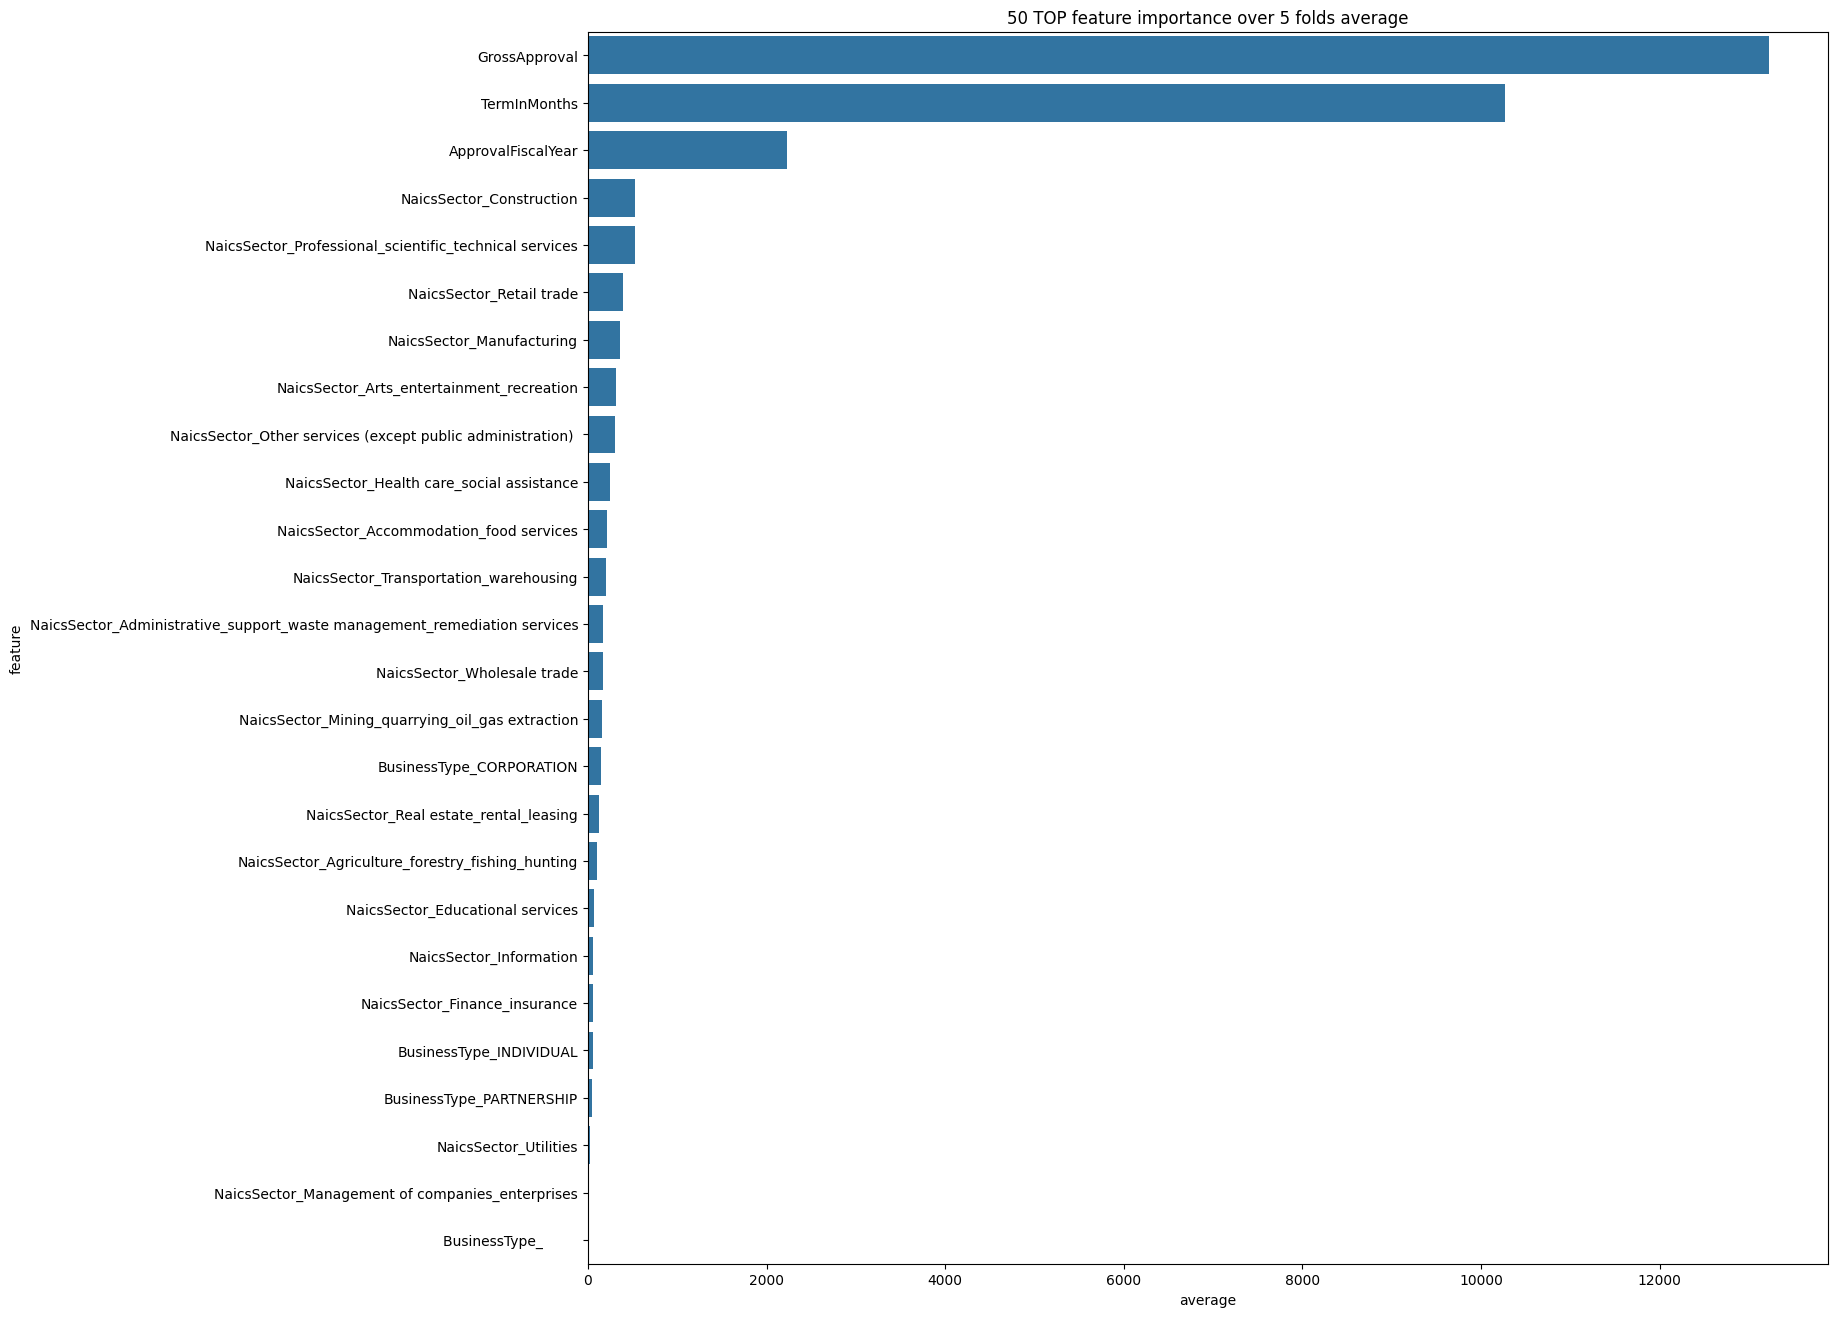

In [33]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

feature_importance['average'] = feature_importance[[f'fold_{fold_n + 1}' for fold_n in range(folds.n_splits)]].mean(axis=1)

plt.figure(figsize=(16, 16))
sns.barplot(data=feature_importance.sort_values(by='average', ascending=False), x='average', y='feature');
plt.title('50 TOP feature importance over {} folds average'.format(folds.n_splits));

上からGrossApproval, TermInMonths, ApprovalFiscalYearが重要と算出されました。

これらの特徴量を利用して新たな特徴量を作成するのも良いかもしれません。

それでは最後に予測結果と正解データの当たり外れの傾向を見てみましょう。

傾向を見ることで次にどのように予測モデルを作るのかの参考になります。
例えば、1と予測する数が少なければ、学習データの0の割合を減らすであったり、1と判定する予測をの基準を引き下げるなどが考えられます。

混合行列で確認ができます。

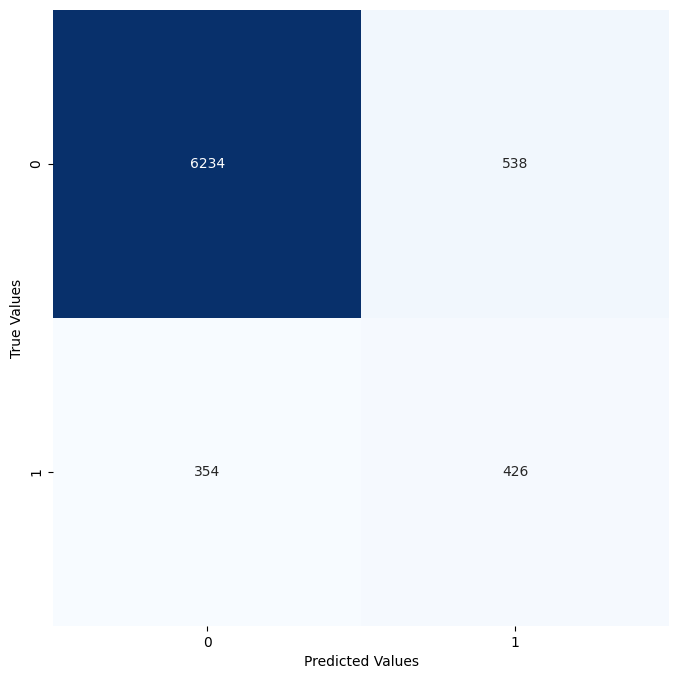

In [34]:
plt.figure(figsize=(8,8))
mat = confusion_matrix(target, (y_oof >= threshold).astype(int)) # Confusion matrix
# Plot Confusion matrix
sns.heatmap(mat.T, square=True, annot=True, cbar=False, cmap=plt.cm.Blues, fmt="d")
plt.xlabel('Predicted Values')
plt.ylabel('True Values');
plt.show();

混合行列は、
- 左上が、正しく0を0として予測できている数(真陰性)
- 左下が、正解の1を0として予測した数(偽陰性)
- 右上が、正解の0を1として予測した数(偽陽性)
- 右下が、正しく1を1として予測した数(真陽性)

となります。

これを見ると全体的に1の予測が少ないように見えますが、学習元のデータの比率を確認して、1の予測がどれくらいあるのか確認してみましょう。

In [35]:
# 学習データ全体の1の割合
print(target.mean())

0.12764830508474576


In [36]:
# 予測結果の1の割合
print((y_oof >= threshold).astype(int).mean())

0.10328389830508475


全体的な割合は近いですが、もしかすると1と予測する割合を増やすことで、もっとスコアを上げることができるかもしれません。

# 7. 提出
それでは最後に学習したモデルをテストデータに適用して予測をし提出を行います。

In [37]:
predict = y_test_pred.mean(axis=1)

In [38]:
print(predict[:5])

[2.85848170e-03 3.11260405e-08 2.99026418e-08 5.77906417e-02
 2.12058212e-03]


それでは提出ファイルを作成します。

提出ファイルの見本はsample_submit.csvにあります。

In [39]:
#sample_submit.csvを読み込みます。
submit = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MUFG Data Science Challenge 2025/BasicCamp/data/sample_submit.csv", header=None)
submit.head()

,0,1
0,7553,0
1,7554,0
2,7555,0
3,7556,0
4,7557,0


In [40]:
print(submit.shape)

(7552, 2)


In [41]:
print(submit[1].mean())

0.09083686440677965


0にid、1にLoanStatusの予測ラベルを入力する場所があります。

sample_submitのidはテストデータのidの数値と同じため、1の列の部分をモデルで予測した値に変更すると提出できます。

In [42]:
# また予測値は0か1限定で、データ型をintにする必要があります
submit[1] = (predict >= threshold).astype(int)

In [43]:
# 確認してみましょう
submit.head()

,0,1
0,7553,0
1,7554,0
2,7555,0
3,7556,0
4,7557,0


In [44]:
# 1の予測が見えなかったので、平均値で確認します
print(submit[1].mean())

0.10407838983050847


割合を見るに1の部分が予測データに変わっていることが確認できました!

ではこのデータをcsv形式で保存し提出しましょう!

`to_csv()`でデータをcsvに保存することができます!

In [45]:
# submission.csvでデータを保存(提出様式はindex=False, header=Noneとなります。)
submit.to_csv("submission.csv", index=False, header=None)

In [ ]:
# google driveに直接予測結果を保存する場合は、以下のコメントアウト(#)を外して、ドライブ上にある保存先のフォルダ(ディレクトリ)を指定してください。
# submit.to_csv("/content/drive/MyDrive/Colab Notebooks/submission.csv", index=False, header=None)

これで本チュートリアルは終了です。

早速作成したsubmission.csvをダウンロードして早速提出してみましょう。ここまでのチュートリアルお疲れ様でした!

# モデル精度向上のための発展的アプローチ
ベースラインモデルの構築完了は、あくまで改善プロセスのスタート地点です。以下の観点から試行錯誤を繰り返すことで、さらなるスコアアップが期待できます。

1. **アルゴリズムの多様化**: XGBoost や CatBoost とのアンサンブル、あるいはニューラルネットワークの検討。
2. **ハイパーパラメータ最適化**: Optuna 等を用いた自動チューニングの実施。
3. **高度な特徴量エンジニアリング**: 変数間の相互作用の考慮や、ドメイン知識に基づく新規変数の生成。
4. **ポストプロセッシング**: 予測確率に対する閾値の最適化。
5. **生成AIの活用**: ChatGPT 等を利用した特徴量生成のアイデア出しや、エラーのデバッグ効率化。